**Setup toàn bộ môi trường + dataset + code**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== ĐI VỀ /content =====
%cd /content
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================

!gdown --id 1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q dataset_BTXRD.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================

!mv dataset_BTXRD Prompt-Guided-XRay-Segmentation/

# =========================================================
# ĐI VÀO PROJECT
# =========================================================

%cd Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown

print("\nSETUP DONE!")

/content
CUDA: True
GPU: Tesla T4
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 183 (delta 64), reused 86 (delta 36), pack-reused 62 (from 1)
Receiving objects: 100% (183/183), 36.63 MiB | 16.49 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3
From (redirected): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3&confirm=t&uuid=990c2857-3470-46d1-83a4-1844d7adab3a
To: /content/dataset_BTXRD.zip
100% 1.50G/1.50G [00:11<00:00, 125MB/s]

DATASET STRUCTURE:
test  train  val
/content/Prompt-Guided-XRay-Segmentat

**Train**

In [ ]:
# =========================================================
# TRAIN
# =========================================================

!python train.py

Thí nghiệm B | Device: cuda | EncoderPrompt: True
Epoch 1/100 [Train]:   1% 6/465 [00:04<05:42,  1.34it/s, loss=1.6157]
Traceback (most recent call last):
  File "/content/Prompt-Guided-XRay-Segmentation/train.py", line 240, in <module>
    main()
  File "/content/Prompt-Guided-XRay-Segmentation/train.py", line 179, in main
    train_loss += loss.item()
                  ^^^^^^^^^^^
KeyboardInterrupt


**Checkpoint_PGA**

In [4]:
# ====== ĐÃ XÓA: TẢI PGA CHECKPOINT TỪ GOOGLE DRIVE ======
# Checkpoint được lấy trực tiếp từ kết quả train (checkpoints/pga_unet_expB_best.pth)
# !pip install -q gdown
# import gdown, os
# SAVE_DIR = 'checkpoints/'
# os.makedirs(SAVE_DIR, exist_ok=True)
# file_id = '1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z'
# output_path = os.path.join(SAVE_DIR, 'pga_unet_expB_best.pth')
# url = f'https://drive.google.com/uc?id={file_id}'
# gdown.download(url, output_path, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_expB_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 84.5MB/s]


✅ Đã lưu tại: checkpoints/pga_unet_expB_best.pth


**Checkpoint_PL**

In [5]:
# ====== ĐÃ XÓA: TẢI MOBILENETV4 CHECKPOINT TỪ GOOGLE DRIVE ======
# MobileNetV4 chỉ dùng để test pipeline sàng lọc, không cần thiết cho PGA-UNet
# !pip install -q gdown
# import gdown, os
# SAVE_DIR = 'checkpoints/'
# os.makedirs(SAVE_DIR, exist_ok=True)
# file_id = '1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx'
# output_path = os.path.join(SAVE_DIR, 'best_mobilenetv4.pth')
# url = f'https://drive.google.com/uc?id={file_id}'
# gdown.download(url, output_path, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx
From (redirected): https://drive.google.com/uc?id=1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx&confirm=t&uuid=a658bc7c-cdaa-4c5a-a73c-20d85e3c5ac9
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/best_mobilenetv4.pth
100%|██████████| 39.7M/39.7M [00:00<00:00, 131MB/s]


✅ Đã lưu tại: checkpoints/best_mobilenetv4.pth


## Bước 2 – Thí nghiệm A (baseline sạch, zoom-out only)
# Trong train.py: EXPERIMENT='A', USE_ENCODER_PROMPT=False

In [ ]:
# @title
"""
test_exp_scenarios.py
=====================
Đánh giá 3 kịch bản prompt: 100% zoom-out | 100% shift | mixed 70-30
Visualize danh sách ảnh: mỗi ảnh hiện 2 kịch bản (zoom-out và shift)

Cách chạy:
    python test_exp_scenarios.py
"""

import os
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CẤU HÌNH – chỉnh tại đây
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
BATCH_SIZE         = 4
USE_ENCODER_PROMPT = True   # ← True = bật encoder gate / False = tắt

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

# THAY ĐỔI: Danh sách 3 ảnh muốn visualize
VIS_IMAGES = [
    "IMG001768.png",
    "IMG001538.png",
    "IMG001100.png"
]

# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    """
    Giữ lại vùng liên thông lớn nhất (Largest Connected Component).
    Lọc sạch các điểm nhiễu vụn hoặc đường viền artifact do model sinh ra.
    """
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:  # Chỉ có nền (background)
        return binary_map

    # Tìm label có diện tích (area) lớn nhất, bỏ qua label 0 (nền)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    """95% Hausdorff Distance (pixel). Thấp hơn = tốt hơn."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    """
    Center-Based Localization [0,1]. Cao hơn = tốt hơn.
    Trả về None nếu GT rỗng (sample bị bỏ qua khi tính mean).
    """
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def get_centroid(binary_map: np.ndarray):
    """
    Tính tâm của binary mask trên không gian 512x512.
    Trả về (cx, cy) – cx là trục ngang (cột), cy là trục dọc (hàng).
    Trả về (None, None) nếu mask rỗng.
    """
    if binary_map.sum() == 0:
        return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())   # (cx, cy)

# =========================================================
# ĐÁNH GIÁ 1 KỊCH BẢN
# =========================================================

def run_eval(model: torch.nn.Module, prompt_mode: str) -> dict:
    """Chạy inference toàn bộ test set, trả về dict 6 metric."""
    ds = BTXRD_Dataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            preds   = (torch.sigmoid(model(images, prompts)) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()          # predicted mask (512x512)
                gm = masks[b, 0].cpu().numpy()           # GT mask (512x512)

                # --- ÁP DỤNG HẬU XỬ LÝ LỌC NHIỄU BIÊN ---
                pm = extract_lcc(pm)

                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()

                all_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                all_iou.append( (tp + smooth) / (tp + fp + fn + smooth))
                all_pre.append( (tp + smooth) / (tp + fp + smooth))
                all_rec.append( (tp + smooth) / (tp + fn + smooth))
                all_hd95.append(calc_hd95(pm.astype(bool), gm.astype(bool)))

                cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
                if cbl is not None:
                    all_cbl.append(cbl)

    return {
        'dice': np.mean(all_dice),
        'iou':  np.mean(all_iou),
        'pre':  np.mean(all_pre),
        'rec':  np.mean(all_rec),
        'hd95': np.mean(all_hd95),
        'cbl':  np.mean(all_cbl) if all_cbl else 0.0,
        'n':    len(all_dice),
    }

# =========================================================
# ĐÁNH GIÁ 3 KỊCH BẢN
# =========================================================

def evaluate_all(model: torch.nn.Module) -> dict:
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    print("\n" + "=" * 72)
    print(f"  ĐÁNH GIÁ 3 KỊCH BẢN  |  encoder_prompt = {enc_tag}")
    print("=" * 72)

    scenarios = {
        '100% Zoom-out': 'zoom_out',
        '100% Shift':    'shift',
        'Mixed 70-30':   'mixed_7_3',
    }

    results = {}
    for name, mode in scenarios.items():
        results[name] = run_eval(model, mode)
        print(f"  [{name}]  {results[name]['n']} samples – xong.")

    # In bảng kết quả
    header = (f"\n{'Kịch bản':<16} {'Dice↑':>7} {'IoU↑':>7} "
              f"{'Pre↑':>7} {'Rec↑':>7} {'HD95↓':>8} {'CBL↑':>7} {'N':>5}")
    print(header)
    print("-" * 68)
    for name, r in results.items():
        print(f"{name:<16} {r['dice']:>7.4f} {r['iou']:>7.4f} "
              f"{r['pre']:>7.4f} {r['rec']:>7.4f} "
              f"{r['hd95']:>8.2f} {r['cbl']:>7.4f} {r['n']:>5}")
    return results

# =========================================================
# VISUALIZE 1 ẢNH – 2 KỊCH BẢN (zoom-out & shift)
# =========================================================

def visualize_two_scenarios(model: torch.nn.Module, img_name: str):
    # ── Đọc ảnh và annotation ─────────────────────────────
    img_path  = os.path.join(TEST_IMAGE_DIR, img_name)
    json_path = os.path.join(TEST_JSON_DIR, os.path.splitext(img_name)[0] + '.json')
    if not os.path.exists(img_path):
        print(f"  ⚠  Không tìm thấy: {img_path}")
        return

    image_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    orig_h, orig_w = image_cv.shape

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Lấy polygon đầu tiên hợp lệ
    target_shape = next(
        (s for s in data.get('shapes', [])
         if s.get('shape_type') == 'polygon' and len(s.get('points', [])) > 2),
        data['shapes'][0] if data.get('shapes') else None
    )
    if target_shape is None:
        print(f"  ⚠  Không tìm thấy polygon trong {img_name}")
        return

    points = np.array(target_shape['points'])
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    gt_w,  gt_h  = x_max - x_min, y_max - y_min

    # GT mask gốc (để resize)
    mask_cv = np.zeros((orig_h, orig_w), dtype=np.uint8)
    cv2.fillPoly(mask_cv, [points.astype(np.int32)], 255)

    # Dùng Dataset helper để tạo heatmap đồng nhất với training
    ds_h = BTXRD_Dataset(
        TEST_IMAGE_DIR, TEST_JSON_DIR,
        img_size=IMG_SIZE, is_train=False
    )
    r = (ds_h.zoom_ratio[0] + ds_h.zoom_ratio[1]) / 2   # ratio cố định cho test

    def make_heatmap(bx0, bx1, by0, by1):
        """Tạo heatmap rồi resize về 512x512."""
        pm = ds_h.create_plateau_heatmap(
            [bx0, by0, bx1, by1], orig_h, orig_w
        )
        return cv2.resize(pm, (IMG_SIZE, IMG_SIZE))

    # ── Prompt zoom-out: mở rộng đều 4 phía ──────────────
    pm_zoom = make_heatmap(
        max(0,      x_min - gt_w * r),
        min(orig_w, x_max + gt_w * r),
        max(0,      y_min - gt_h * r),
        min(orig_h, y_max + gt_h * r),
    )

    # ── Prompt shift: dịch tâm sang phải + xuống, vẫn overlap GT ──
    shift_x = gt_w * ds_h.shift_ratio * 0.6   # 60% max shift → fixed cho test
    shift_y = gt_h * ds_h.shift_ratio * 0.4
    new_cx  = (x_min + x_max) / 2 + shift_x
    new_cy  = (y_min + y_max) / 2 + shift_y
    half_w  = gt_w * (1 + r) / 2
    half_h  = gt_h * (1 + r) / 2
    pm_shift = make_heatmap(
        max(0,      new_cx - half_w),
        min(orig_w, new_cx + half_w),
        max(0,      new_cy - half_h),
        min(orig_h, new_cy + half_h),
    )

    # ── Resize ảnh & mask về 512x512 ─────────────────────
    image_r = cv2.resize(image_cv, (IMG_SIZE, IMG_SIZE))
    mask_r  = cv2.resize(mask_cv,  (IMG_SIZE, IMG_SIZE),
                         interpolation=cv2.INTER_NEAREST)
    img_np  = image_r / 255.0
    gt_np   = (mask_r > 127).astype(np.float32)

    img_t = torch.from_numpy(
        (image_r.astype(np.float32) / 255.0 - 0.5) / 0.5
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    # Tâm GT tính trên không gian 512x512
    cx_gt, cy_gt = get_centroid(gt_np.astype(bool))

    # ── Vẽ figure ────────────────────────────────────────
    scenarios_vis = [
        ('Zoom-out (fixed)', pm_zoom),
        ('Shift (fixed)',    pm_shift),
    ]

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    fig.suptitle(
        f"Thí nghiệm A/B – Zoom-out vs Shift  |  {img_name}  |  encoder={enc_tag}",
        fontsize=14, fontweight='bold'
    )
    col_titles = ["Ảnh gốc", "Prompt heatmap", "Ground Truth", "Dự đoán",
                  "Biên + Tâm (Dice | HD95 | CBL)"]
    for c, t in enumerate(col_titles):
        axes[0][c].set_title(t, fontsize=11, fontweight='bold')

    model.eval()
    with torch.no_grad():
        for row, (scenario_name, pm_np) in enumerate(scenarios_vis):
            pm_t = torch.from_numpy(pm_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
            pred_np = (torch.sigmoid(model(img_t, pm_t)) > 0.5).float()[0, 0].cpu().numpy()

            # --- ÁP DỤNG HẬU XỬ LÝ LỌC NHIỄU BIÊN TRƯỚC KHI VẼ ---
            pred_np = extract_lcc(pred_np)

            # Tâm dự đoán – tính trên 512x512 sau khi đã lọc nhiễu
            cx_pred, cy_pred = get_centroid(pred_np.astype(bool))

            tp   = (pred_np * gt_np).sum()
            dice = (2 * tp + 1e-5) / (pred_np.sum() + gt_np.sum() + 1e-5)
            hd95 = calc_hd95(pred_np.astype(bool), gt_np.astype(bool))
            cbl  = calc_cbl(pred_np.astype(bool),  gt_np.astype(bool)) or 0.0

            # Col 0: Ảnh gốc
            axes[row][0].imshow(img_np, cmap='gray')
            axes[row][0].set_ylabel(scenario_name, fontsize=11, fontweight='bold',
                                    rotation=0, labelpad=72, va='center')

            # Col 1: Prompt heatmap
            axes[row][1].imshow(img_np, cmap='gray')
            axes[row][1].imshow(
                np.ma.masked_where(pm_np < 0.05, pm_np),
                cmap='magma', alpha=0.65
            )

            # Col 2: Ground Truth overlay xanh + contour + tâm GT
            axes[row][2].imshow(img_np, cmap='gray')
            green = np.zeros((*gt_np.shape, 4), dtype=np.float32)
            green[gt_np == 1] = [0, 1, 0, 0.35]
            axes[row][2].imshow(green)
            if gt_np.max() > 0:
                axes[row][2].contour(gt_np, [0.5], colors='lime', linewidths=1.5)
            if cx_gt is not None:
                axes[row][2].plot(
                    cx_gt, cy_gt, 'o',
                    color='lime', ms=9,
                    markeredgecolor='black', markeredgewidth=1.2,
                    label='Tâm GT'
                )
                axes[row][2].legend(fontsize=7, loc='lower right')

            # Col 3: Dự đoán overlay đỏ + contour + tâm pred
            axes[row][3].imshow(img_np, cmap='gray')
            red = np.zeros((*pred_np.shape, 4), dtype=np.float32)
            red[pred_np == 1] = [1, 0, 0, 0.35]
            axes[row][3].imshow(red)
            if pred_np.max() > 0:
                axes[row][3].contour(pred_np, [0.5], colors='red', linewidths=1.5)
            if cx_pred is not None:
                axes[row][3].plot(
                    cx_pred, cy_pred, 'o',
                    color='red', ms=9,
                    markeredgecolor='white', markeredgewidth=1.2,
                    label='Tâm Pred'
                )
                axes[row][3].legend(fontsize=7, loc='lower right')

            # Col 4: Biên GT (xanh) + Biên Pred (đỏ nét đứt)
            #        + tâm GT + tâm Pred + đường nối 2 tâm
            axes[row][4].imshow(img_np, cmap='gray')
            if gt_np.max() > 0:
                axes[row][4].contour(gt_np,   [0.5],
                                     colors='lime', linewidths=2)
            if pred_np.max() > 0:
                axes[row][4].contour(pred_np, [0.5],
                                     colors='red', linewidths=2,
                                     linestyles='--')
            if cx_gt is not None:
                axes[row][4].plot(cx_gt, cy_gt, 'o',
                                  color='lime', ms=8,
                                  markeredgecolor='black', markeredgewidth=1.2,
                                  label='Tâm GT')
            if cx_pred is not None:
                axes[row][4].plot(cx_pred, cy_pred, 'o',
                                  color='red', ms=8,
                                  markeredgecolor='white', markeredgewidth=1.2,
                                  label='Tâm Pred')
            # Đường nối 2 tâm → thấy trực quan độ lệch CBL
            if cx_gt is not None and cx_pred is not None:
                axes[row][4].plot(
                    [cx_gt, cx_pred], [cy_gt, cy_pred],
                    '--', color='yellow', lw=1.5, alpha=0.85
                )
            axes[row][4].set_title(
                f"Dice:{dice:.3f} | HD95:{hd95:.1f}px | CBL:{cbl:.3f}",
                fontsize=9, fontweight='bold'
            )
            axes[row][4].legend(fontsize=7, loc='lower right')

            for ax in axes[row]:
                ax.axis('off')

    plt.tight_layout()
    plt.show()

# =========================================================
# ENTRY POINT
# =========================================================
if __name__ == "__main__":
    model = PGA_UNet(
        in_channels=1,
        n_classes=1,
        use_encoder_prompt=USE_ENCODER_PROMPT
    ).to(DEVICE)
    model.load_state_dict(
        torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    )
    model.eval()
    print(f"Model loaded: {MODEL_PATH}")
    print(f"Device: {DEVICE}  |  Encoder prompt: {'ON' if USE_ENCODER_PROMPT else 'OFF'}")

    # 1. Đánh giá số liệu 3 kịch bản
    results = evaluate_all(model)

    # 2. Lưu kết quả CSV
    import csv
    os.makedirs("results", exist_ok=True)
    csv_path = "results/pga_unet_expB_results.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["model", "prompt_mode", "dice", "iou", "precision", "recall", "hd95", "cbl", "n_samples"])
        mode_map = {"100% Zoom-out": "zoom_out", "100% Shift": "shift", "Mixed 70-30": "mixed_7_3"}
        for name, r in results.items():
            writer.writerow([
                "PGA-UNet Exp B",
                mode_map.get(name, name),
                f"{r['dice']:.4f}", f"{r['iou']:.4f}",
                f"{r['pre']:.4f}",  f"{r['rec']:.4f}",
                f"{r['hd95']:.4f}", f"{r['cbl']:.4f}",
                r["n"]
            ])
    print(f"\nKet qua da luu: {csv_path}")

    # 3. Vòng lặp show 3 ảnh, mỗi ảnh 2 kịch bản
    for img_name in VIS_IMAGES:
        visualize_two_scenarios(model, img_name)

**GradCAM + IPR**

🔍 Đang quét 174 mẫu vùng nền đen với 5 vòng lặp IPR...



————————————————————————— TRỰC QUAN HÓA 5 VÒNG IPR —————————————————————————


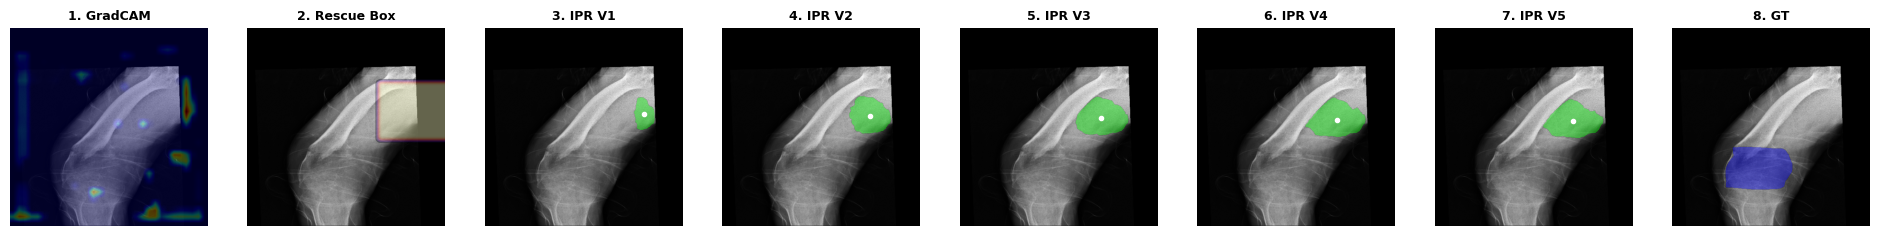

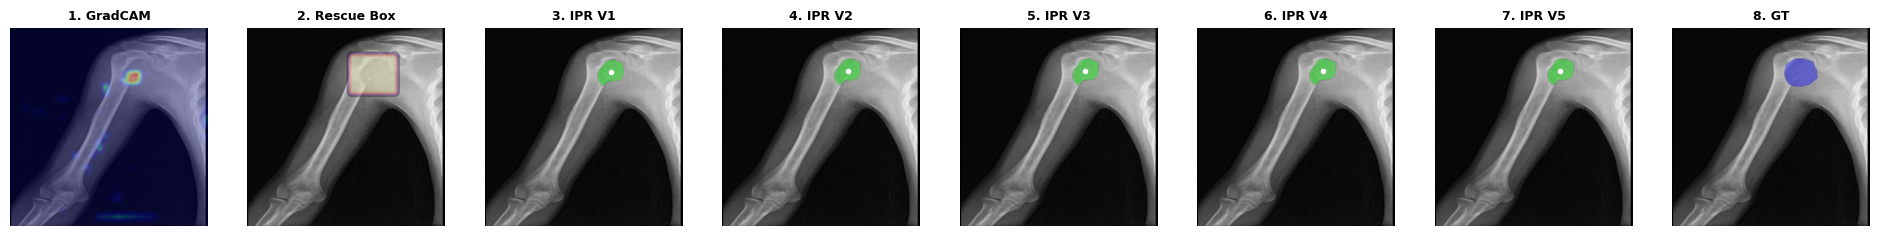

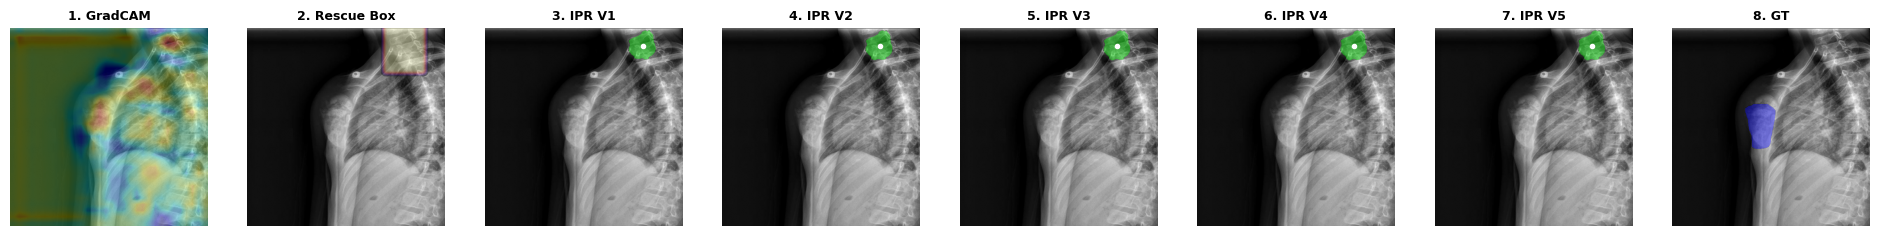

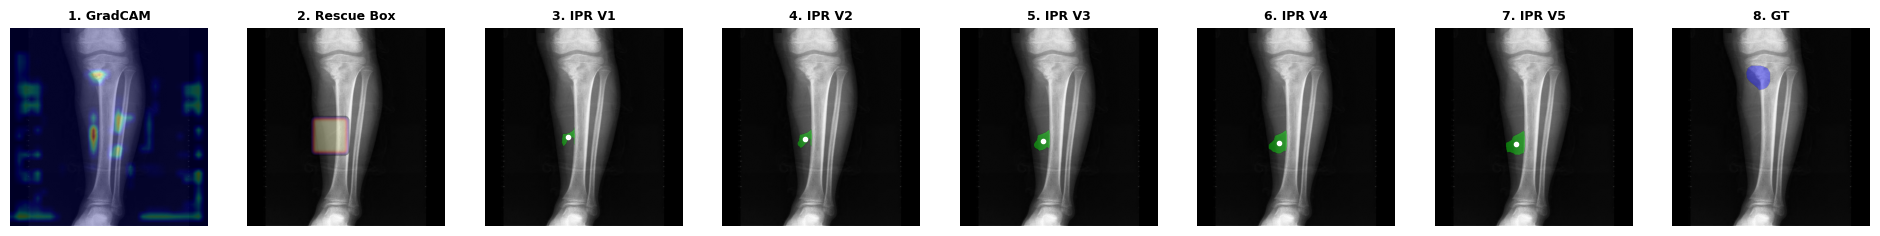

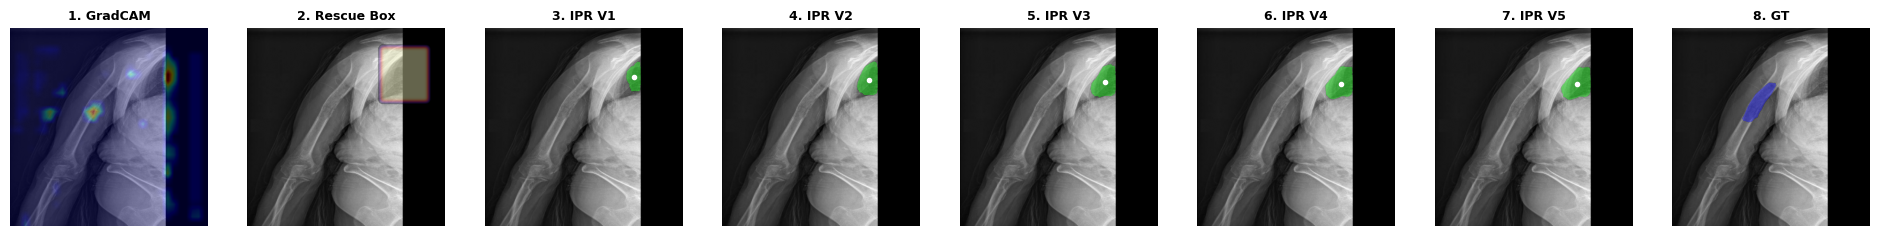

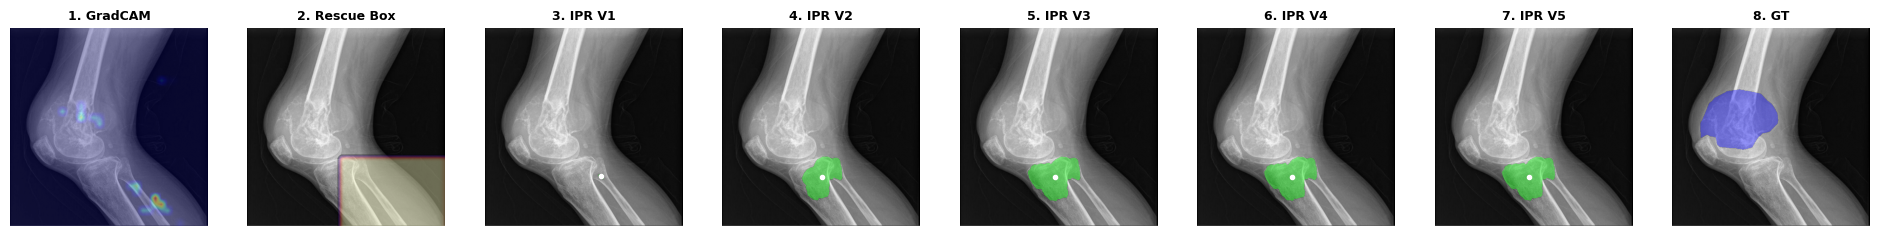

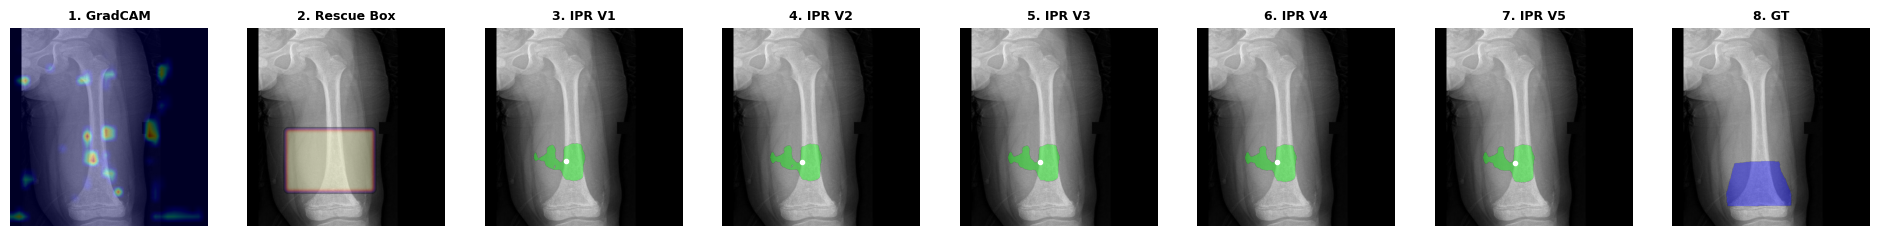

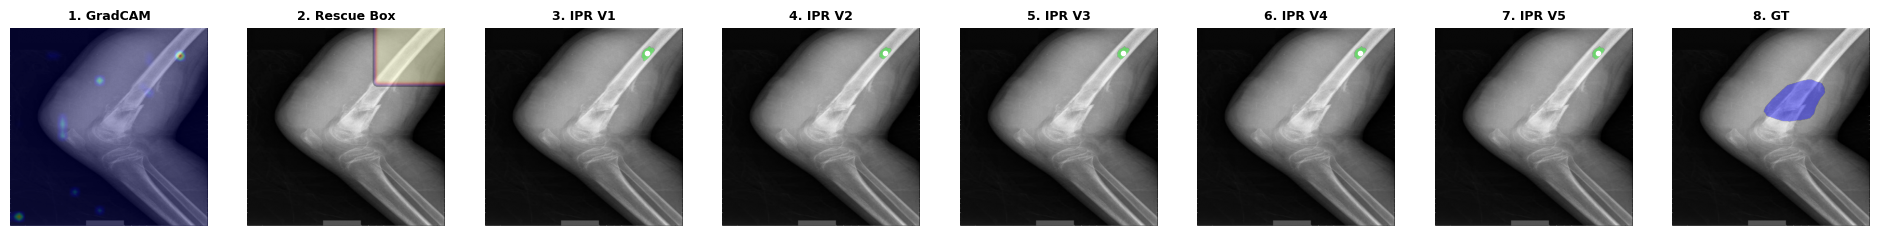

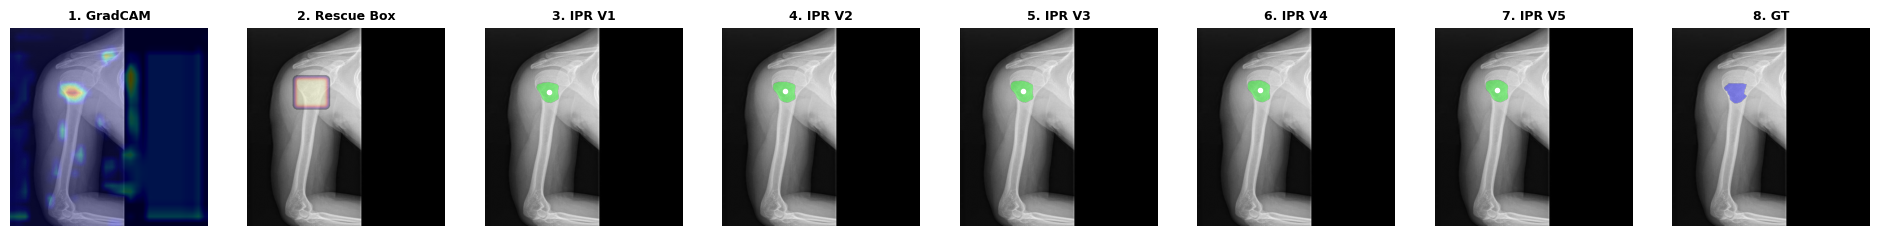

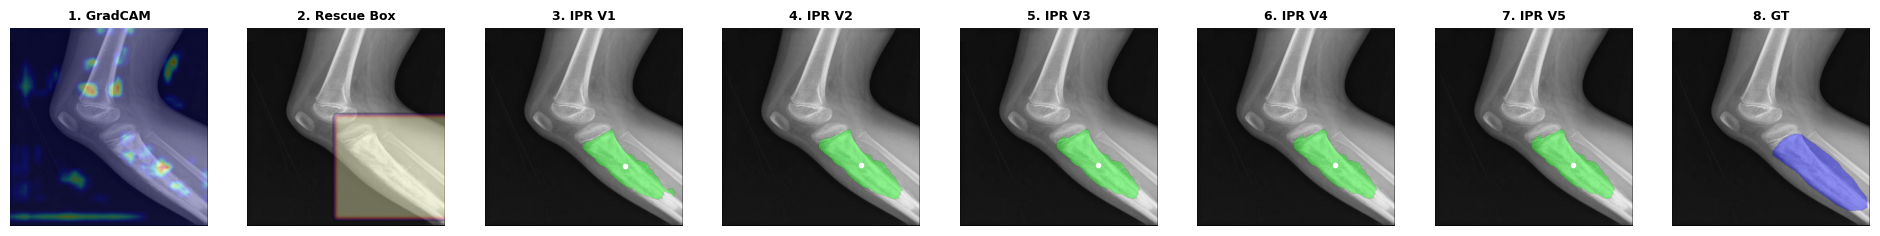


Giai đoạn    |    Dice↑ |     IoU↑ |     CBL↑
--------------------------------------------------
Vòng 1       |   0.2516 |   0.2046 |   0.3268
Vòng 2       |   0.2840 |   0.2415 |   0.3443
Vòng 3       |   0.2956 |   0.2558 |   0.3510
Vòng 4       |   0.2988 |   0.2602 |   0.3543
Vòng 5       |   0.2997 |   0.2618 |   0.3556


In [ ]:
# @title
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# 1. CẤU HÌNH (THAY ĐỔI TẠI ĐÂY)
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
USE_ENCODER_PROMPT = True

# --- THÔNG SỐ IPR ---
NUM_IPR_STEPS      = 5       # <--- BIẾN KHAI BÁO SỐ VÒNG LẶP THEO Ý MUỐN
NUM_VISUALIZE      = 10       # Số lượng ảnh muốn hiển thị mẫu

# --- THÔNG SỐ PHÒNG VỆ ---
DARK_PIXEL_THRESHOLD = -0.80
DARK_RATIO_LIMIT     = 0.70

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

# =========================================================
# 2. HELPERS (METRICS, GRADCAM, CENTROID)
# =========================================================
def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    if binary_map.sum() == 0: return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1: return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_metrics(pm, gm):
    pm, gm = (pm > 0.5).astype(np.float32), (gm > 0.5).astype(np.float32)
    tp = (pm * gm).sum()
    fp = (pm * (1 - gm)).sum()
    fn = ((1 - pm) * gm).sum()
    dice = (2 * tp + 1e-5) / (2 * tp + fp + fn + 1e-5)
    iou = (tp + 1e-5) / (tp + fp + fn + 1e-5)
    return dice, iou

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0 or pred_bin.sum() == 0: return 0.0
    ys, xs = np.where(gt_bin); yp, xp = np.where(pred_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + 1e-6
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 + (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def compute_gradcam(model, image_tensor):
    gradients, activations = [], []
    def fwd_hook(module, inp, out):
        activations.append(out)
        out.register_hook(lambda g: gradients.append(g))
    hook = model.center.register_forward_hook(fwd_hook)
    model.eval()
    img_t = image_tensor.clone().detach().to(DEVICE)
    zero_prompt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = model(img_t, zero_prompt)
    model.zero_grad()
    out.sum().backward()
    hook.remove()
    if not gradients: return None
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map > 0.5)
    return float(xs.mean()), float(ys.mean())

# =========================================================
# 3. CHƯƠNG TRÌNH ĐÁNH GIÁ TỰ ĐỘNG
# =========================================================
def run_dynamic_ipr_evaluation(model):
    test_ds = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    r = (test_ds.zoom_ratio[0] + test_ds.zoom_ratio[1]) / 2

    # Khởi tạo stats dựa trên biến NUM_IPR_STEPS
    stats = {f'Vòng {v}': {'dice': [], 'iou': [], 'cbl': []} for v in range(1, NUM_IPR_STEPS + 1)}
    vis_data = []

    print(f"🔍 Đang quét 174 mẫu vùng nền đen với {NUM_IPR_STEPS} vòng lặp IPR...")

    model.eval()
    for i, (img_t, mask_t, _) in enumerate(tqdm(loader, leave=False)):
        img_np, gt_np = img_t[0,0].numpy(), mask_t[0, 0].numpy()
        if gt_np.sum() == 0: continue

        # Logic lọc vùng nền đen (Dark Background Check)
        box_w, box_h = 80, 80
        best_dark_ratio = -1
        corners = [(10, 10), (IMG_SIZE-box_w-10, 10), (10, IMG_SIZE-box_h-10), (IMG_SIZE-box_w-10, IMG_SIZE-box_h-10)]
        for (bx, by) in corners:
            roi = img_np[by:by+box_h, bx:bx+box_w]
            ratio = (roi < DARK_PIXEL_THRESHOLD).sum() / (box_w * box_h)
            best_dark_ratio = max(best_dark_ratio, ratio)

        if best_dark_ratio < DARK_RATIO_LIMIT: continue

        # --- BẮT ĐẦU CỨU HỘ ---
        img_t = img_t.to(DEVICE)
        sal = compute_gradcam(model, img_t)
        if sal is None: continue
        py_curr, px_curr = np.unravel_index(sal.argmax(), sal.shape)

        ys_g, xs_g = np.where(gt_np)
        gt_w, gt_h = xs_g.max()-xs_g.min(), ys_g.max()-ys_g.min()
        bw, bh = gt_w*(1+r), gt_h*(1+r)

        temp_vis = {'sal': sal, 'steps': [], 'gt': gt_np, 'img': img_np}

        # --- CHUỖI LẶP IPR DỰA TRÊN BIẾN KHAI BÁO ---
        for v in range(1, NUM_IPR_STEPS + 1):
            pm = test_ds.create_plateau_heatmap([px_curr-bw/2, py_curr-bh/2, px_curr+bw/2, py_curr+bh/2], IMG_SIZE, IMG_SIZE)
            pm_t = torch.from_numpy(cv2.resize(pm, (IMG_SIZE, IMG_SIZE))).unsqueeze(0).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                prob = torch.sigmoid(model(img_t, pm_t))[0,0].cpu().numpy()
                mask = extract_lcc((prob > 0.5).astype(np.float32))

                # Tính toán Metrics
                dice, iou = calc_metrics(mask, gt_np)
                cbl = calc_cbl(mask, gt_np)

                stats[f'Vòng {v}']['dice'].append(dice)
                stats[f'Vòng {v}']['iou'].append(iou)
                stats[f'Vòng {v}']['cbl'].append(cbl)

                # Cập nhật tâm cho vòng sau (Feedback loop)
                cx, cy = get_centroid(mask)
                if cx is not None:
                    px_curr, py_curr = cx, cy

                # Lưu dữ liệu để vẽ (chỉ lưu cho số lượng ảnh giới hạn)
                if len(vis_data) < NUM_VISUALIZE:
                    temp_vis['steps'].append({'mask': mask, 'cx': cx, 'cy': cy, 'pm': pm})

        if len(vis_data) < NUM_VISUALIZE: vis_data.append(temp_vis)

    # --- HIỂN THỊ HÌNH ẢNH (Dòng chảy IPR) ---
    print("\n" + "—"*25 + f" TRỰC QUAN HÓA {NUM_IPR_STEPS} VÒNG IPR " + "—"*25)
    for data in vis_data:
        # Số lượng cột = 1 (GradCAM) + 1 (Rescue Box) + NUM_IPR_STEPS + 1 (GT)
        num_cols = 3 + NUM_IPR_STEPS
        fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 3, 3))
        img_disp = data['img'] * 0.5 + 0.5

        # 1. GradCAM
        axes[0].imshow(img_disp, cmap='gray'); axes[0].imshow(data['sal'], cmap='jet', alpha=0.3)
        axes[0].set_title("1. GradCAM", fontsize=9, fontweight='bold'); axes[0].axis('off')

        # 2. Rescue Box
        axes[1].imshow(img_disp, cmap='gray'); axes[1].imshow(np.ma.masked_where(data['steps'][0]['pm']<0.1, data['steps'][0]['pm']), cmap='magma', alpha=0.4)
        axes[1].set_title("2. Rescue Box", fontsize=9, fontweight='bold'); axes[1].axis('off')

        # 3. Các vòng IPR
        for v in range(NUM_IPR_STEPS):
            ax = axes[v+2]; ax.imshow(img_disp, cmap='gray')
            mk = data['steps'][v]['mask']
            ov = np.zeros((*mk.shape, 4)); ov[mk > 0.5] = [0, 1, 0, 0.4]
            ax.imshow(ov)
            if data['steps'][v]['cx']:
                ax.plot(data['steps'][v]['cx'], data['steps'][v]['cy'], 'o', color='white', ms=3)
            ax.set_title(f"{v+3}. IPR V{v+1}", fontsize=9, fontweight='bold'); ax.axis('off')

        # 4. Ground Truth
        axes[-1].imshow(img_disp, cmap='gray')
        gt_ov = np.zeros((*data['gt'].shape, 4)); gt_ov[data['gt'] > 0.5] = [0, 0, 1, 0.4]
        axes[-1].imshow(gt_ov); axes[-1].set_title(f"{num_cols}. GT", fontsize=9, fontweight='bold'); axes[-1].axis('off')
        plt.show()

    # --- IN BẢNG THỐNG KÊ TỔNG HỢP ---
    print("\n" + "="*50)
    print(f"{'Giai đoạn':<12} | {'Dice↑':>8} | {'IoU↑':>8} | {'CBL↑':>8}")
    print("-" * 50)
    for v in range(1, NUM_IPR_STEPS + 1):
        k = f'Vòng {v}'
        if stats[k]['dice']:
            print(f"{k:<12} | {np.mean(stats[k]['dice']):>8.4f} | {np.mean(stats[k]['iou']):>8.4f} | {np.mean(stats[k]['cbl']):>8.4f}")
    print("="*50)

if __name__ == "__main__":
    model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    run_dynamic_ipr_evaluation(model)